## 문제
- data 폴더 안에 bodyPerformance.csv 파일을 로드
데이터중 object 형 데이터의 컬럼들은 LabelEncoder를 이용하여 라벨링
- 독립, 종속 변수로 데이터를 나눠준다.
- train, test 데이터를 8:2의 비율로 나눠준다.
- 독립 데이터들은 StandardScaler를 이용하여 스케일링
- 생성된 변수 4개를 Tensor의 형태로 변환
- torch의 분류 분석을 통해서 데이터 학습
- 손실함수는 Adam을 사용하고 lr의 값은 0.01로 설정
- 반복 학습의 횟수는 200회 loss값 확인
- 반복 학습이 끝나면 정확도를 확인

In [1]:
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import accuracy_score
import pandas as pd

In [4]:
body = pd.read_csv("../data/bodyPerformance.csv")

In [5]:
body.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 13393 entries, 0 to 13392
Data columns (total 12 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   age                      13393 non-null  float64
 1   gender                   13393 non-null  object 
 2   height_cm                13393 non-null  float64
 3   weight_kg                13393 non-null  float64
 4   body fat_%               13393 non-null  float64
 5   diastolic                13393 non-null  float64
 6   systolic                 13393 non-null  float64
 7   gripForce                13393 non-null  float64
 8   sit and bend forward_cm  13393 non-null  float64
 9   sit-ups counts           13393 non-null  float64
 10  broad jump_cm            13393 non-null  float64
 11  class                    13393 non-null  object 
dtypes: float64(10), object(2)
memory usage: 1.2+ MB


In [ ]:
# Object형 컬럼을 선택하야 LabelEncoder를 사용하여 라벨링
# Str 형의 데이터를 Int 형태로 자동변환
obj_cols = body.select_dtypes('object').columns.tolist()

for col in obj_cols:
    
    body[col] = LabelEncoder().fit_transform(body[col].values)

In [ ]:
# 해당 데이터를 이용하여 분류 분석 -> 정확도가 얼마나 되는가? -> 분류의 개수를 확인
# class 컬럼의 데이터들의 종류
body['class'].unique()

array([2, 0, 1, 3])

In [25]:
# 독립, 종속으로 데이터를 분할
X = body.drop('class', axis = 1).values
Y = body['class'].values  # values를 붙히는 이유. ndarray로 타입을 고정시키기 위해서
print(type(X), type(Y))

<class 'numpy.ndarray'> <class 'numpy.ndarray'>


In [63]:
X.shape

(13393, 11)

In [26]:
# train, test 데이터 분할
X_train, X_test, Y_train, Y_test = train_test_split(
    X, Y, test_size=0.2, random_state=42
)

In [27]:
print(type(X_train), type(X_test), type(Y_train))

<class 'numpy.ndarray'> <class 'numpy.ndarray'> <class 'numpy.ndarray'>


In [28]:
# 스케일링
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [29]:
print(type(X_train))

<class 'numpy.ndarray'>


In [30]:
# Tensor 타입으로 데이터를 타입 변경
X_train_tensor = torch.tensor(X_train, dtype=torch.float32)
X_test_tensor = torch.tensor(X_test, dtype=torch.float32)

In [33]:
# CrossEntropyLoss 에서 사용할 데이터의 타입을 설정 -> long 타입
Y_train_tensor = torch.tensor(Y_train, dtype=torch.long)
Y_test_tensor = torch.tensor(Y_test, dtype= torch.long)

In [64]:
# 모델 정의
class Bodycls(nn.Module):
    def __init__(self, _dim):
        # _dim : 입력 데이터의 피쳐의 개수를 받아오기 위한 매개변수
        super(Bodycls, self).__init__()
        # Sequential() -> 여러개의 층을 순서대로 실행
        self.model = nn.Sequential(
            nn.Linear(_dim, _dim * 3),    # 11차원의 입력데이터, 22차원의 출력데이터 생성
            # 비선형 활성화 함수 (ReLU, Sigmoid, Tanh)
            nn.ReLU(),
            nn.Linear(_dim * 3, _dim * 2),
            nn.ReLU(),
            nn.Linear(_dim * 2, 4)       
        )
        # self.model = nn.Linear(_dim, 4)
    
    def forward(self, x):
        return self.model(x)

In [65]:
X_train.shape
# (데이터 개수, 열의 개수)

(10714, 11)

In [66]:
# 모델을 생성
body_model = Bodycls(X_train.shape[1])

In [67]:
# 손실, 옵티마이저 생성
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(body_model.parameters(), lr = 0.01)

In [68]:
# 반복 학습
body_model.train()
for epoch in range(200):
    Y_pred = body_model(X_train_tensor)

    loss = criterion(Y_pred, Y_train_tensor)

    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

    if (epoch + 1) % 40 == 0:
        print(f"Epoch : {epoch+1}, Loss : {round(loss.item(), 4)}")

Epoch : 40, Loss : 0.7917
Epoch : 80, Loss : 0.6575
Epoch : 120, Loss : 0.6091
Epoch : 160, Loss : 0.5832
Epoch : 200, Loss : 0.5676


In [69]:
body_model.eval()  # eval() : 해당하는 모델을 학습 -> 평가 모델로 전환
with torch.no_grad():
    out = body_model(X_test_tensor)
    _, pred = torch.max(out,1) # 가장 높은 클래스를 선택
    # 정확도를 계산
    acc = accuracy_score(Y_test, pred)

print("정확도 : ", round(acc,4))

정확도 :  0.7462


In [70]:
# 비선형 활성화 함수 비교
import matplotlib.pyplot as plt

# sin 그래프를 하나 생성
x = torch.linspace(-3, 3, 200).unsqueeze(1)
y = torch.sin(x)

In [73]:
linear_model = nn.Sequential(
    nn.Linear(1, 16),
    nn.Linear(16, 1)
)

In [74]:
relu_model = nn.Sequential(
    nn.Linear(1,16),
    nn.ReLU(),
    nn.Linear(16,1)
)

In [75]:
loss = nn.MSELoss()

opt1 = optim.Adam(linear_model.parameters(), lr = 0.01)
opt2 = optim.Adam(relu_model.parameters(), lr = 0.01)

In [78]:
# 반복학습
for epoch in range(3000):
    # 선형 모델
    pred1 = linear_model(x)
    loss1 = loss(pred1, y)
    opt1.zero_grad()
    loss1.backward()
    opt1.step()

    # 비선형 모델
    pred2 = relu_model(x)
    loss2 = loss(pred2,y)
    opt2.zero_grad()
    loss2.backward()
    opt2.step()

In [79]:
# 예측 결과
linear_pred = linear_model(x).detach()
relu_pred = relu_model(x).detach()

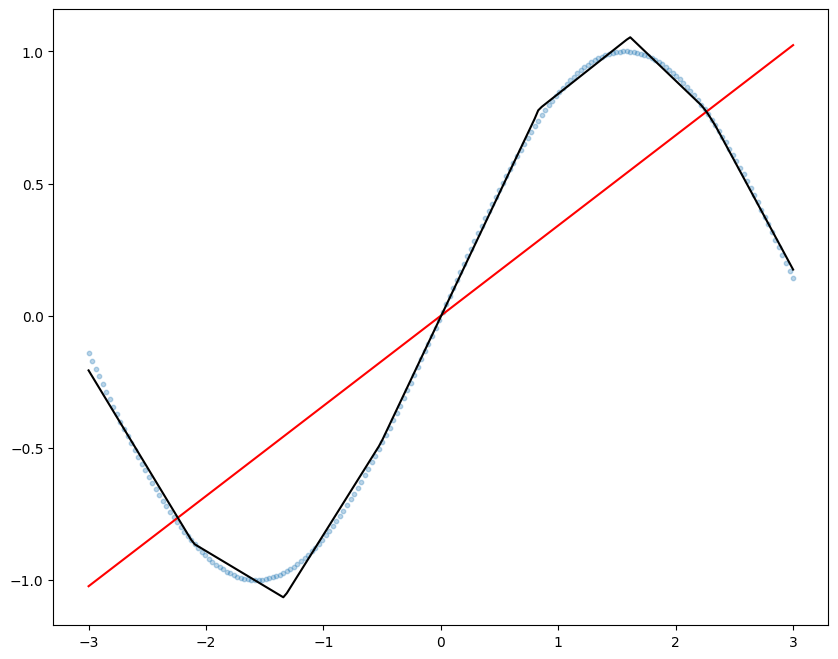

In [82]:
# 시각화
plt.figure(figsize=(10,8))
plt.scatter(x,y, s= 10, alpha=0.3, label = 'Origin Data')
plt.plot(x, linear_pred, color = 'red')
plt.plot(x, relu_pred, color = 'black')